递归是一种解决问题的方法，它包括将一个问题分解成越来越小的子问题，直到得到一个小到可以轻松解决的问题。通常，递归涉及函数调用自身。
### 示例一：计算列表中数字的总和
- **迭代法**
```python
def listsum(numList):
    theSum = 0
    for i in numList:
        theSum = theSum + i
    return theSum

print(listsum([1, 3, 5, 7, 9]))
```

- **递归法**
把列表 `[1, 3, 5, 7, 9]`看成第一个元素 + 剩余列表的和
```python
def listsum(numList):
    if len(numList) == 0:
        return 0   # 当列表只剩一个元素的时候就只剩下自己了（这里是考虑空列表的情况）
    else:
        return numList[0] + listsum(numList[1:])    # 去除第一个元素，然后将剩下后面列表的切片送入自己函数继续求和

print(listsum([1, 3, 5, 7, 9]))
```


### 递归三大定律
#### 必须有基例（Base Case）
递归必须有一个条件，使它能够 **停止**。
如果没有基例，就会 **无限递归最终触发栈溢出**
对应上面示例一的`if len(numList) == 1:  return numList[0]`

#### 必须向基例靠近
每次递归调用时，问题必须变小。
递归不能原地打转，必须朝“更容易解决”的方向推进、
对应上面`listsum`的`listsum(numList[1:])`，每次把列表缩短一个元素

#### 必须调用自己
递归的字面意思。
对应`return numList[0] + listsum(numList[1:])`

递归和 **数学归纳法** 很像，都是在：
- 先解决最简单情况
- 再假设更小的问题可以解决
- 由此构造更大的问题的解

### 示例二：把整数转换成任意进制字符串
把一个十进制整数 n 转成某个进制下的字符串表示。
例如：

- 10 转成十进制字符串："10"
- 10 转成二进制字符串："1010"
- 1453 转成十六进制字符串："5AD"

> 为什么这个问题适合递归？
> 因为一个数在某个进制下的表示可以拆成
> - 更高位部分
> - 当前最低位
> 而更高位部分本身又是一个更小的同类问题


In [ ]:
def toStr(n, base):
    convertString = "123456789ABCDEF"
    if n < base:
        return convertString[n]
    else:
        return toStr(n//base, base) + convertString[int(n % base)]  
        # 商的进制表示 + 余数对应字符

在 Python 中调用函数时，会分配一个 **栈帧** 来存储函数的局部变量。当函数返回时，返回值会留在栈顶供调用函数访问。
**栈帧** 还为函数所使用的变量提供了一个 **作用域**。尽管我们在反复调用同一个函数，但每次调用都会为函数的局部变量创建一个新的作用域。

### 示例三：谢尔宾斯基三角形（Sierpinski Triangle）
谢尔宾斯基三角形是一个经典的**分形（fractal）**图形。
它最重要的特征是 **自相似（self-similarity）**：
- 一个大三角形里面包含三个更小的三角形
- 每个小三角形又和原图形长得相似
- 所以非常适合用递归来画

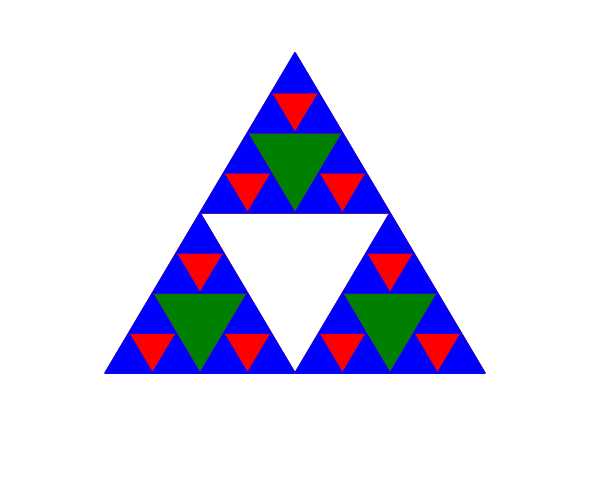

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 绘制三角形（替换原turtle的drawTriangle，功能完全一致）
def drawTriangle(points, color, ax):
    triangle = plt.Polygon(points, color=color)
    ax.add_patch(triangle)

# 中点计算（和你原来的代码一模一样）
def getMid(p1, p2):
    return ((p1[0]+p2[0]) / 2, (p1[1]+p2[1]) / 2)

# 谢尔宾斯基递归（你的核心代码100%保留，仅替换绘图对象）
def sierpinski(points, degree, ax):
    colormap = ['blue', 'red', 'green', 'white', 'yellow', 'violet', 'orange']
    drawTriangle(points, colormap[degree], ax)
    if degree > 0:
        sierpinski([points[0],
                    getMid(points[0], points[1]),
                    getMid(points[0], points[2])],
                   degree-1, ax)
        sierpinski([points[1],
                    getMid(points[0], points[1]),
                    getMid(points[1], points[2])],
                   degree-1, ax)
        sierpinski([points[2],
                    getMid(points[0], points[2]),
                    getMid(points[1], points[2])],
                   degree-1, ax)

# ---------------------- Jupyter专用：自动绘图 ----------------------
plt.figure(figsize=(6, 5))  # 设置画布大小
ax = plt.gca()
ax.set_xlim(-150, 150)     # X轴范围
ax.set_ylim(-100, 120)     # Y轴范围
ax.axis('off')             # 隐藏坐标轴，和原图一样干净

# 你的原始坐标 + 阶数
myPoints = [[-100, -50], [0, 100], [100, -50]]
sierpinski(myPoints, 3, ax)

# 直接在Jupyter中显示图片（核心！无弹窗、无报错）
plt.tight_layout()
plt.show()

### 示例四：汉诺塔
汉诺塔有三根柱子、一摞大小不同的圆盘。
初始时所有盘子都在第一根柱子上，并且：
- 小盘在上
- 大盘在下
目标是把整座塔从起始柱移动到目标柱
- 限制条件：
  1. 一次只能移动一个盘子
  2. 大盘不能压在小盘上面
![](/img/python/hanoi.png)
这一段是非常关键的，涉及把汉诺塔和递归联系起来的本质思考。
比如说，如果要把高度为n的塔从A移到C，可以拆成3步：
1. 先把上面的n-1个盘子，从A借助C移到B
2. 再把最大的第n个原来在A的盘子移到C
3. 最后把n-1个盘子，从B借助A移到C
这三步里，第1步和第3步本身又是同样的问题。所以递归结构非常自然。

| 盘子数量 `n` | 执行步骤 | 具体移动操作 | 核心说明 |
| :---------- | :------- | :----------- | :------- |
| **n = 1** | 递归出口（仅1步） | 唯一的盘子从 **A → C** | 最小子问题，直接解决，无需递归 |
| **n = 2** | 步骤1 | 上层小盘子（n-1=1个）从 **A 借助 C 移到 B** | 挪走小盘子，才能移动下方大盘子 |
| | 步骤2 | 最大的第2个盘子从 **A → C** | 将底盘移至目标柱C |
| | 步骤3 | 上层小盘子（n-1=1个）从 **B 借助 A 移到 C** | 完成全部2个盘子的移动 |
| **n = 3** | 步骤1 | 上层2个盘子（n-1=2个）从 **A 借助 C 移到 B** | 递归自动解决n=2的子问题，无需手动拆解 |
| | 步骤2 | 最大的第3个盘子从 **A → C** | 将底盘移至目标柱C |
| | 步骤3 | 上层2个盘子（n-1=2个）从 **B 借助 A 移到 C** | 再次递归解决n=2的子问题，完成整体移动 |

In [ ]:
# 移动 height 个盘子，从 fromPole → toPole，借助 withPole
def moveTower(height, fromPole, toPole, withPole):
    if height >= 1:
        # 第一步：将n-1个盘子，从fromPole移到withPole，借助toPole
        moveTower(height-1, fromPole, withPole, toPole)
        # 第二步
        moveDisk(fromPole, toPole)
        # 第三步：将n-1个盘子，从withPole移到toPole，借助fromPole
        moveTower(height-1, withPole, toPole, fromPole)

def moveDisk(fromPole, toPole):
    print("moving disk from", fromPole, "to", toPole)

上面汉诺塔的基例可以理解为 **塔高为 0 时，无需移动，直接返回**。
每次递归都让塔高不断减小向基例靠近。
> 如果真的要显式维护盘子，通常会想到用 3 个栈；而当前程序实际上是借助 Python 的调用栈在工作
#### 递推关系
这里T(n) = 2T(n-1) + 1
所以使用高中学过的数列还是啥的知识可以简单推出通式为T(n) = 2^n - 1

也就是对于 n 个盘子的 **最少移动次数**。
### 示例五：迷宫搜索（Exploring a Maze）
> 这个比较复杂，而且涉及turtle这种大一才会去看的东西

### 动态规划
动态规划常用于 **优化问题或最值问题**。
比如：
- 最短路径
- 最少硬币数
- 最优划分
- 最优组合

比如说下面的最少找零问题：假设顾客投入一张1美元纸币，购买一件37美分的商品。如何用最少的硬币找零？
一般而言，美式硬币的金额是1, 5, 10, 25。这里使用贪心策略25 + 25 + 10 + 1 + 1 + 1得到 6 枚；
但是倘若我们把硬币集合变成1, 5, 10, 21, 25，贪心还是会先拿尽可能大的硬币得到6的结果，但最优解却是21 + 21 + 21 共 3 枚；

用递归去做的话，对于金额change：
如果刚好等于某个硬币值，那么答案就是1
否则：
- 枚举所有不超过change的硬币c
- 取1 + recMC(change - c)的最小值

In [ ]:
def recMC(coinValueList, change):
    minCoins = change
    if change in coinValueList:
        return 1
    else:
        for i in [c for c in coinValueList if c <= change]:
        # 这上面的for循环其实相当于 for i in coinValueList:
        # 只是需要额外筛选出小于等于change的硬币，避免不必要的递归调用
        # 比如找6块钱不能给25块的硬币
            numCoins = 1 + recMC(coinValueList, change - i)
            if numCoins < minCoins:
                minCoins = numCoins
    return minCoins

print(recMC([1, 5, 10, 25], 63))

6


这个递归其实挺好理解的：
- 先拿一枚值为 i 的硬币
- 剩余金额 change - i 递归求最优
- 最后再加上当前这 1 枚
$$
numCoins = \min\left\{
\begin{array}{l}
1 + numCoins(originalamount - 1) \\
1 + numCoins(originalamount - 5) \\
1 + numCoins(originalamount - 10) \\
1 + numCoins(originalamount - 25)
\end{array}
\right.
$$

![](/img/python/call-tree.png)
然而，我的超级至尊笔记本i9-13900HX算这个逼玩意算了13秒，足见效率问题。
距离来说：
```
recMC(11)
├─ recMC(10)
├─ recMC(6)
│  ├─ recMC(5)
│  └─ recMC(1)  👈 第1次计算
└─ recMC(1)     👈 第2次计算（重叠！重复计算！）
```
同一个子问题会被反复计算很多次，这类现象叫 **重叠子问题（overlapping subproblems）**。
#### 记忆化搜索（Memoization / Caching）
既然某些子问题会反复算很多次，那就把已经算出的结果存起来。
下次再需要时直接查表，不重复递归计算。

In [5]:
def refDC(coinValueList, change, knownResults):
    # knownResults是一个数组，用来存每个金额的最优解
    minCoins = change
    if change in coinValueList:
        knownResults[change] = 1    # 当前最优解自然就是1咯
        return 1
    elif knownResults[change] > 0:  # 已经计算过的金额直接返回结果
        return knownResults[change]
    else:
        for i in [c for c in coinValueList if c < change]:
            numCoins = 1 + refDC(coinValueList, change - i, knownResults)
            if numCoins < minCoins:
                minCoins = numCoins
                knownResults[change] = minCoins

    return minCoins
print(refDC([1, 5, 10, 25], 63, [0]*64))

6


执行代码用时在0.1秒以下，这才是我处理器的实力嘛！
#### 自底向上
上面还不算真正的动态规划，我们的核心思想不是等递归碰到子问题时再顺手存结果，而是：
从最小子问题开始，**系统地一步步推到目标问题**
对于找零问题，就是：
- 先求 1 分
- 再求 2 分
- 再求 3 分
...
- 一直到 change

这样做的好处是当你在求 cents 时，所有更小金额的最优解都已经算好了

In [ ]:
def dpMakeChange(coinValueList, change, minCoins):
    for cents in range(change + 1):     # 左闭右开
        coinCount = cents               # 最坏情况就是全用1分硬币，比如11分最多用11枚1分
        for j in [c for c in coinValueList if c <= cents]:
        # 枚举所有不超过当前金额 cents 的硬币
        # cents：你现在要凑的钱数
        # j：你现在打算用的这一枚硬币
        # cents - j：你在用掉这一枚硬币之后，还剩多少钱需要凑
            if minCoins[cents - j] + 1 < coinCount:
                # minCoins[cents - j]   →   剩下的1元钱，已经算好的【最少硬币数】（1个）
                # + 1                   →   加上我现在用的这1枚5元硬币
                # coinCount             →   这个方案总共用 2 枚硬币
                coinCount = minCoins[cents - j] + 1
                # 假如说是第一次的话，coinCount是11，minCoins[cents - j] + 1是2，那么就更新coinCount为2
        minCoins[cents] = coinCount
    return minCoins[change]


#### 状态转移
> 假设凑齐 `cents` 金额时，**最后一枚使用的硬币面值为 `j`**（`j` 是 ≤ `cents` 的合法硬币），那么：
1.  先凑齐 **`cents - j`**（用掉1枚 `j` 面值硬币后，剩下的金额）；
2.  剩下的 `cents - j` 金额，其最小硬币数已经通过前面的循环计算完成（存在 `minCoins[cents - j]` 中，直接复用，不重复计算）；
3.  总硬币数 = 凑齐 `cents - j` 的最小硬币数 + 1（这1枚就是我们当前选用的 `j` 面值硬币）。

简单说：**用1枚 `j` 硬币，把大问题（凑 `cents`）拆成小问题（凑 `cents - j`），小问题的答案已经算好，直接用就好**。
用 `dp[cents]` 表示「凑齐 `cents` 金额所需的最小硬币数」（对应代码中的 `minCoins[cents]`），状态转移方程如下：
$$dp[cents] = \min\left\{ dp[cents - j] + 1 \right\}$$


| 符号/表达式 | 具体含义 | 对应代码中的变量 |
| :---------- | :------- | :--------------- |
| `dp[cents]` | 凑齐 `cents` 金额的**最小硬币数**（最终要计算的结果） | `minCoins[cents]` |
| `j` | 当前尝试使用的硬币面值（必须 ≤ `cents`，合法硬币） | 内层循环中的 `j`（`[c for c in coinValueList if c <= cents]`） |
| `cents - j` | 用掉1枚 `j` 面值硬币后，**剩下的金额** | `cents - j`（代码中直接使用） |
| `dp[cents - j]` | 凑齐「剩下的金额」所需的最小硬币数（已提前计算好，直接复用） | `minCoins[cents - j]` |
| `dp[cents - j] + 1` | 「剩下金额的最小硬币数」+「当前这1枚 `j` 硬币」，即当前方案的总硬币数 | `minCoins[cents - j] + 1` |
| `min{}` | 遍历所有合法硬币 `j`，取所有方案中「总硬币数最少」的那个，作为 `dp[cents]` 的最终值 | 代码中用 `if minCoins[cents - j] + 1 < coinCount` 更新 `coinCount`，最终赋值给 `minCoins[cents]` |

以 **硬币 `[1,5]`，计算 `cents=6`** 为例，代入方程拆解：
1.  合法硬币 `j` 只能是 `1` 和 `5`（均 ≤ 6）；
2.  当 `j=1` 时：
    - `cents - j = 6 - 1 = 5`
    - `dp[5]` 已提前计算好（=1，即1枚5元硬币）
    - 当前方案硬币数：`dp[5] + 1 = 1 + 1 = 2`
3.  当 `j=5` 时：
    - `cents - j = 6 - 5 = 1`
    - `dp[1]` 已提前计算好（=1，即1枚1元硬币）
    - 当前方案硬币数：`dp[1] + 1 = 1 + 1 = 2`
4.  取两个方案的最小值：`min{2, 2} = 2`，即 `dp[6] = 2`（对应代码中 `minCoins[6] = 2`）。

动态规划为什么比递归更好？
因为它避免了：
- 重复计算
- 深层递归调用
- 大量函数调用开销
它的特点是：
- 系统填表
- 每个子问题只解一次
- 解更大问题时直接复用小问题答案

In [6]:
def dpMakeChange(coinValueList, change, minCoins, coinUsed):
    for cents in range(change + 1):
        coinCount = cents
        newCoin = 1

        for j in [c for c in coinValueList if c <= cents]:
            if minCoins[cents - j] + 1 < coinCount:
                coinCount = minCoins[cents - j] + 1
                newCoin = j
            
        minCoins[cents] = coinCount
        coinUsed[cents] = newCoin
    return minCoins[change]

def printCoins(coinUsed, change):
    coin = change
    while coin > 0:
        thisCoin = coinUsed[coin]
        print(thisCoin)
        coin = coin - thisCoin

amnt = 63
clist = [1, 5, 10, 21, 25]
coinsUsed = [0] * (amnt + 1)
coinCount = [0] * (amnt + 1)

print("Making change for", amnt, "requires")
print(dpMakeChange(clist, amnt, coinCount, coinsUsed), "coins")
print("They are:")
printCoins(coinsUsed, amnt)
print("The used list is as follows:")
print(coinsUsed)

Making change for 63 requires
3 coins
They are:
21
21
21
The used list is as follows:
[1, 1, 1, 1, 1, 5, 1, 1, 1, 1, 10, 1, 1, 1, 1, 5, 1, 1, 1, 1, 10, 21, 1, 1, 1, 25, 1, 1, 1, 1, 5, 10, 1, 1, 1, 10, 1, 1, 1, 1, 5, 10, 21, 1, 1, 10, 21, 1, 1, 1, 25, 1, 10, 1, 1, 5, 10, 1, 1, 1, 10, 1, 10, 21]


扩展版：不仅求最少数量，还要知道用了哪些硬币，其核心要素就在于对每个金额，记录最后一次选的是哪枚硬币。
这样就可以回溯复用前面的答案，和图算法里记录 pred 前驱指针类似：
- 图最短路中，pred 记录“从哪来”
- 这里 coinsUsed 记录“最后用了哪枚硬币”
都属于为了恢复完整解，而额外记录决策路径。